In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
print("Imports are done")

Imports are done


In [3]:
df = pd.read_csv('D:/stroke-prediction/data/healthcare_stroke.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [4]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [7]:
print(df['stroke'].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


In [8]:
print(df['stroke'].value_counts(normalize=True) * 100)

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


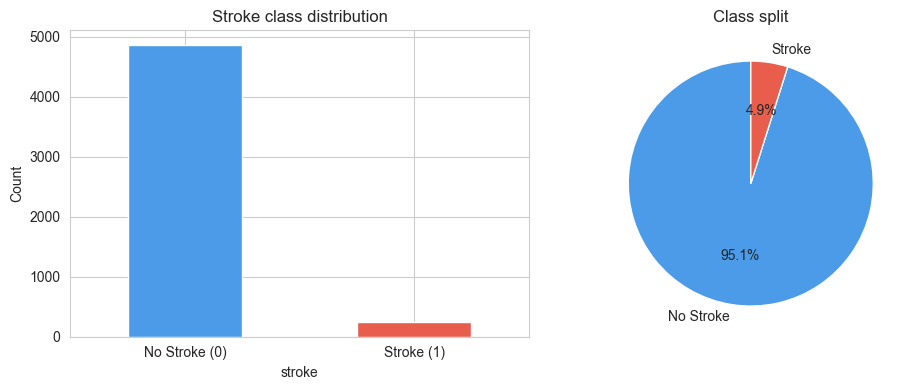

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
df['stroke'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C9BE8','#E85D4C'])
axes[0].set_title('Stroke class distribution')
axes[0].set_xticklabels(['No Stroke (0)', 'Stroke (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
df['stroke'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['No Stroke', 'Stroke'],
    colors=['#4C9BE8','#E85D4C'],
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Class split')

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

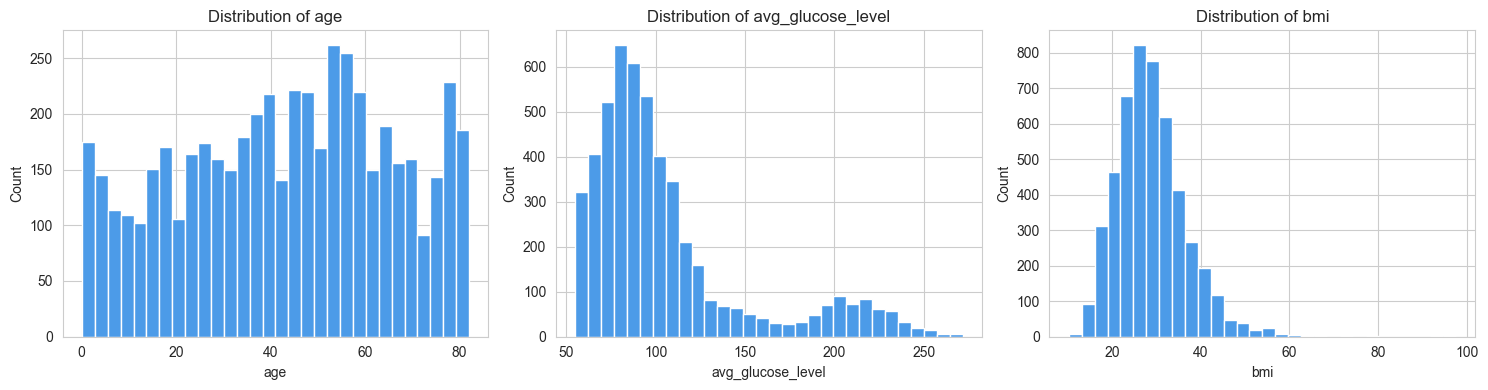

In [10]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#4C9BE8', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

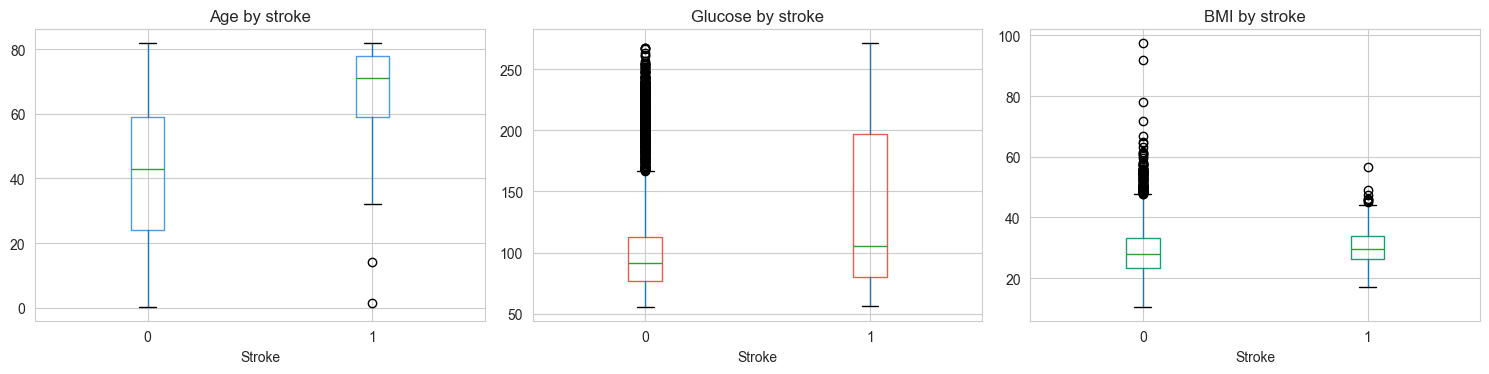

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age vs stroke
df.boxplot(column='age', by='stroke', ax=axes[0], 
           boxprops=dict(color='#4C9BE8'))
axes[0].set_title('Age by stroke')
axes[0].set_xlabel('Stroke')

# Glucose vs stroke
df.boxplot(column='avg_glucose_level', by='stroke', ax=axes[1],
           boxprops=dict(color='#E85D4C'))
axes[1].set_title('Glucose by stroke')
axes[1].set_xlabel('Stroke')

# BMI vs stroke
df.boxplot(column='bmi', by='stroke', ax=axes[2],
           boxprops=dict(color='#1D9E75'))
axes[2].set_title('BMI by stroke')
axes[2].set_xlabel('Stroke')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../data/feature_vs_stroke.png', dpi=150, bbox_inches='tight')
plt.show()

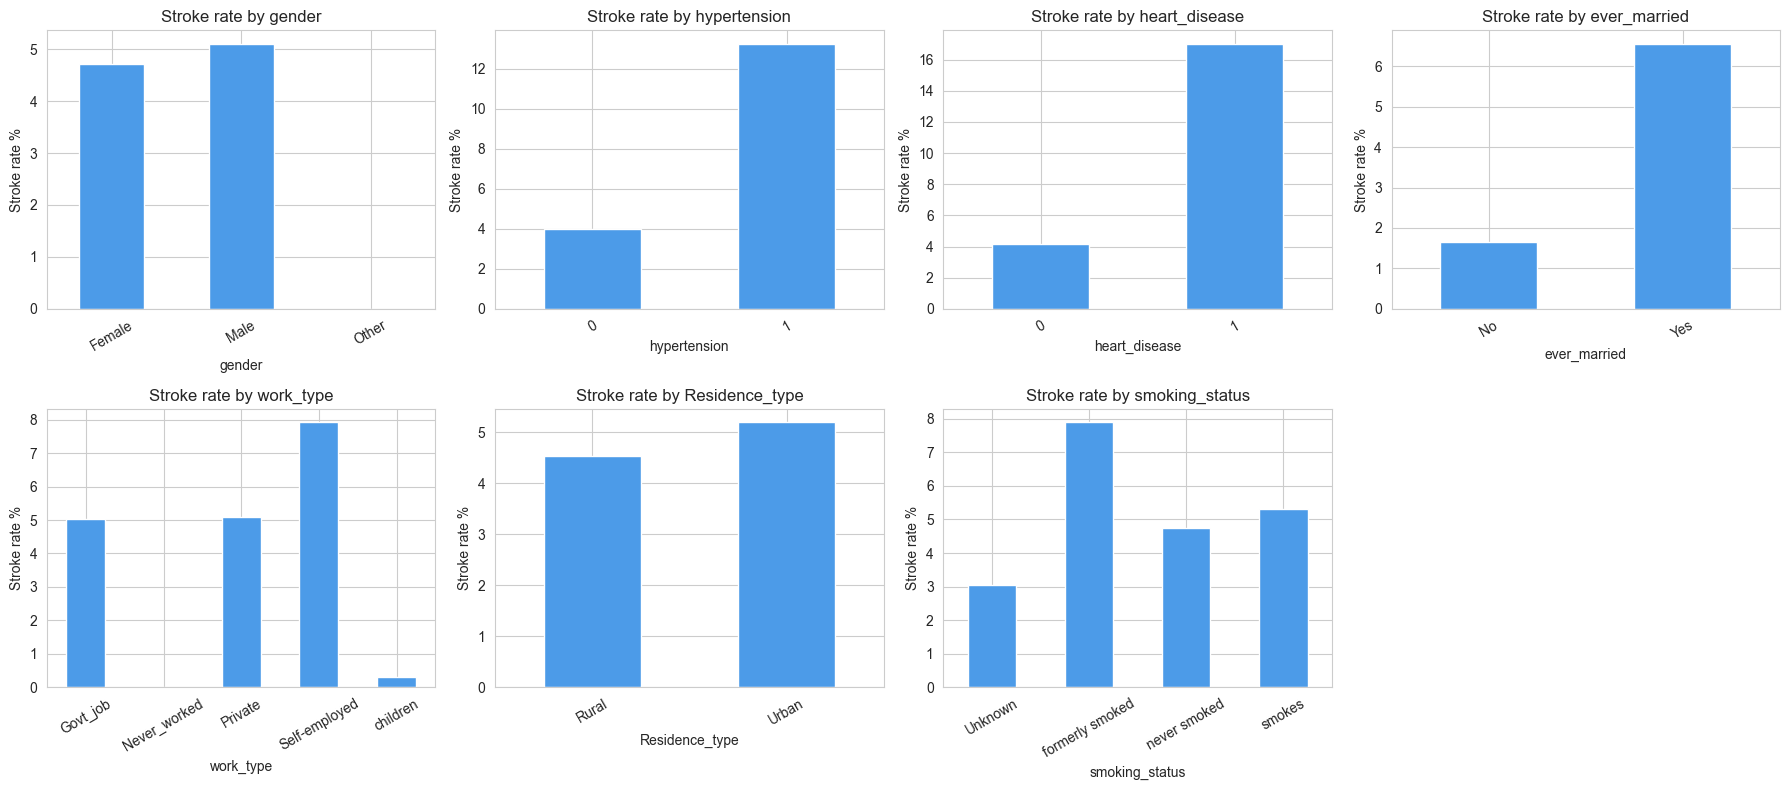

In [12]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 
            'ever_married', 'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stroke_rate = df.groupby(col)['stroke'].mean() * 100
    stroke_rate.plot(kind='bar', ax=axes[i], color='#4C9BE8', edgecolor='white')
    axes[i].set_title(f'Stroke rate by {col}')
    axes[i].set_ylabel('Stroke rate %')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../data/categorical_stroke_rates.png', dpi=150, bbox_inches='tight')
plt.show()

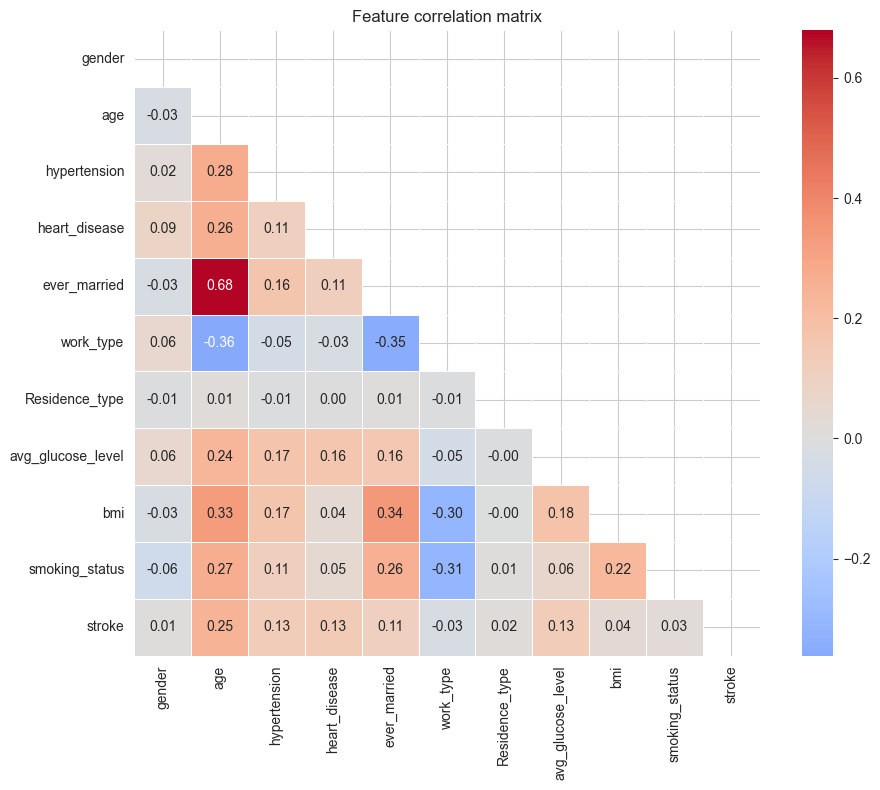

In [13]:
# Encode categoricals temporarily just for correlation
df_corr = df.copy()
le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

plt.figure(figsize=(10, 8))
corr = df_corr.drop('id', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Drop id column
df_clean = df.drop('id', axis=1).copy()

# Fix gender - 'Other' has only 1 row, replace with mode
df_clean['gender'] = df_clean['gender'].replace('Other', df_clean['gender'].mode()[0])

# Impute missing BMI with median
imputer = SimpleImputer(strategy='median')
df_clean['bmi'] = imputer.fit_transform(df_clean[['bmi']])

# --- Feature Engineering ---

# 1. Age-Glucose interaction (captures elderly diabetic high-risk group)
df_clean['age_glucose'] = df_clean['age'] * df_clean['avg_glucose_level']

# 2. Age group bins (clinical risk brackets)
df_clean['age_group'] = pd.cut(df_clean['age'],
    bins=[0, 18, 40, 60, 80, 100],
    labels=['child', 'young_adult', 'middle_aged', 'senior', 'elderly'])

# 3. Combined comorbidity risk flag
df_clean['high_risk_comorbidity'] = (
    (df_clean['hypertension'] == 1) &
    (df_clean['heart_disease'] == 1)
).astype(int)

# Verify
print("Missing values after imputation:")
print(df_clean.isnull().sum())
print("\nNew features added: age_glucose, age_group, high_risk_comorbidity")
print("Shape:", df_clean.shape)

Missing values after imputation:
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                      0
smoking_status           0
stroke                   0
age_glucose              0
age_group                0
high_risk_comorbidity    0
dtype: int64

New features added: age_glucose, age_group, high_risk_comorbidity
Shape: (5110, 14)


In [27]:
# Fix age_group dtype before encoding
df_clean['age_group'] = df_clean['age_group'].astype(str)

# One-hot encode categorical columns
cat_cols_encode = ['gender', 'work_type', 'Residence_type', 'smoking_status', 'age_group']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols_encode, drop_first=False)

# Convert bool columns to int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after encoding:", df_encoded.shape)
print("Columns:", list(df_encoded.columns))

Shape after encoding: (5110, 27)
Columns: ['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'bmi', 'stroke', 'age_glucose', 'high_risk_comorbidity', 'gender_Female', 'gender_Male', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Rural', 'Residence_type_Urban', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'age_group_child', 'age_group_elderly', 'age_group_middle_aged', 'age_group_senior', 'age_group_young_adult']


In [28]:
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train size: (4088, 26)
Test size: (1022, 26)

Train class distribution:
stroke
0    95.132094
1     4.867906
Name: proportion, dtype: float64

Test class distribution:
stroke
0    95.107632
1     4.892368
Name: proportion, dtype: float64


In [29]:
num_features = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])  # transform only - no fit

print("Scaling done")
print("Sample scaled values:")
X_train[num_features].describe().round(2)

Scaling done
Sample scaled values:


,age,avg_glucose_level,bmi
count,4088.00,4088.00,4088.00
mean,-0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.92,-1.13,-2.39
25%,-0.77,-0.64,-0.66
50%,0.07,-0.32,-0.10
75%,0.78,0.17,0.50
max,1.71,3.66,8.85


In [30]:
import joblib

# Save for use in Phase 3
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

# Save scaler - needed at prediction time
joblib.dump(scaler, '../data/scaler.pkl')
joblib.dump(list(X_train.columns), '../data/feature_columns.pkl')

print("All preprocessed data saved to data/")
print("Feature count:", X_train.shape[1])

All preprocessed data saved to data/
Feature count: 26


In [31]:
print(f"Feature count: {X_train.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(X_train.columns, 1):
    print(f"{i:2}. {col}")

Feature count: 26

All columns:
 1. age
 2. hypertension
 3. heart_disease
 4. ever_married
 5. avg_glucose_level
 6. bmi
 7. age_glucose
 8. high_risk_comorbidity
 9. gender_Female
10. gender_Male
11. work_type_Govt_job
12. work_type_Never_worked
13. work_type_Private
14. work_type_Self-employed
15. work_type_children
16. Residence_type_Rural
17. Residence_type_Urban
18. smoking_status_Unknown
19. smoking_status_formerly smoked
20. smoking_status_never smoked
21. smoking_status_smokes
22. age_group_child
23. age_group_elderly
24. age_group_middle_aged
25. age_group_senior
26. age_group_young_adult


In [32]:
print(X_train.shape)
print(y_train.value_counts())

(4088, 26)
stroke
0    3889
1     199
Name: count, dtype: int64


In [33]:
# New imports not used in Phase 2
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb
import optuna
import shap

print("Phase 3 imports done")
print("X_train shape:", X_train.shape)
print("y_train distribution:")
print(y_train.value_counts())

Phase 3 imports done
X_train shape: (4088, 26)
y_train distribution:
stroke
0    3889
1     199
Name: count, dtype: int64


In [35]:
# Fix ever_married encoding - convert Yes/No to 1/0
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['ever_married'] = le.fit_transform(X_train['ever_married'])
X_test['ever_married']  = le.transform(X_test['ever_married'])

# Verify no more string columns
print("Dtypes check - any non-numeric?")
print(X_train.dtypes[X_train.dtypes == 'object'])
print("\nIf empty above - all columns are numeric, good to go")
print("\never_married unique values:", X_train['ever_married'].unique())

Dtypes check - any non-numeric?
Series([], dtype: object)

If empty above - all columns are numeric, good to go

ever_married unique values: [1 0]


In [36]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print("\nSMOTE added", len(X_train_sm) - len(X_train), "synthetic stroke samples")

Before SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64

After SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64

SMOTE added 3690 synthetic stroke samples


In [37]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    roc_auc = roc_auc_score(y_test, y_prob)
    f1      = f1_score(y_test, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Model: {name}  |  Threshold: {threshold}")
    print(f"{'='*50}")
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, 
          target_names=['No Stroke', 'Stroke']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return roc_auc, f1, y_prob

print("Evaluation function ready")

Evaluation function ready


In [38]:
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_sm, y_train_sm)

lr_auc, lr_f1, lr_prob = evaluate_model("Logistic Regression", lr, X_test, y_test)


Model: Logistic Regression  |  Threshold: 0.5
ROC-AUC : 0.8402
F1 Score: 0.0702

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.95      0.99      0.97       972
      Stroke       0.29      0.04      0.07        50

    accuracy                           0.95      1022
   macro avg       0.62      0.52      0.52      1022
weighted avg       0.92      0.95      0.93      1022

Confusion Matrix:
[[967   5]
 [ 48   2]]


C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
rf = RandomForestClassifier(
    n_estimators=100, random_state=42,
    class_weight='balanced', n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

rf_auc, rf_f1, rf_prob = evaluate_model("Random Forest", rf, X_test, y_test)


Model: Random Forest  |  Threshold: 0.5
ROC-AUC : 0.7568
F1 Score: 0.0645

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.95      0.99      0.97       972
      Stroke       0.17      0.04      0.06        50

    accuracy                           0.94      1022
   macro avg       0.56      0.51      0.52      1022
weighted avg       0.91      0.94      0.93      1022

Confusion Matrix:
[[962  10]
 [ 48   2]]


In [40]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0, 0.5),
        'scale_pos_weight'  : trial.suggest_float('scale_pos_weight', 1, 10),
        'random_state'      : 42,
        'eval_metric'       : 'auc',
        'use_label_encoder' : False
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_test, y_test)],
              verbose=False)
    y_prob = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\nBest ROC-AUC:", round(study.best_value, 4))
print("Best params:", study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:26:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:26:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:26:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:26:04] WARNING: C:\actions-r


Best ROC-AUC: 0.8201
Best params: {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.1109890597005268, 'subsample': 0.8866115986697991, 'colsample_bytree': 0.7916940448804747, 'min_child_weight': 6, 'gamma': 0.45689243821611697, 'scale_pos_weight': 9.211258015868712}


In [41]:
best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric']  = 'auc'
# Removed use_label_encoder - deprecated in newer XGBoost

xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_auc, xgb_f1, xgb_prob = evaluate_model(
    "XGBoost (Optuna tuned)", xgb_model, X_test, y_test
)


Model: XGBoost (Optuna tuned)  |  Threshold: 0.5
ROC-AUC : 0.8201
F1 Score: 0.2595

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.98      0.82      0.89       972
      Stroke       0.16      0.68      0.26        50

    accuracy                           0.81      1022
   macro avg       0.57      0.75      0.58      1022
weighted avg       0.94      0.81      0.86      1022

Confusion Matrix:
[[794 178]
 [ 16  34]]


Default threshold (0.5) F1: 0.2595
Optimal threshold (0.62) F1: 0.2959


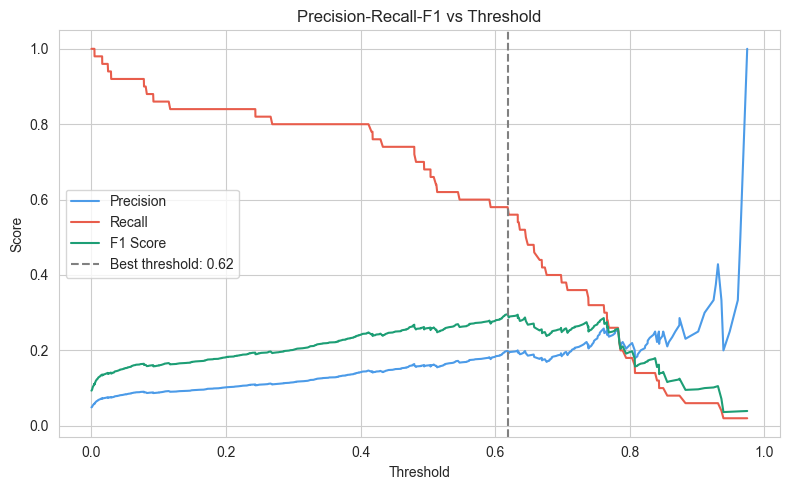


Final evaluation at optimal threshold:

Model: XGBoost (optimal threshold)  |  Threshold: 0.618506669998169
ROC-AUC : 0.8201
F1 Score: 0.2959

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.98      0.88      0.93       972
      Stroke       0.20      0.58      0.30        50

    accuracy                           0.86      1022
   macro avg       0.59      0.73      0.61      1022
weighted avg       0.94      0.86      0.89      1022

Confusion Matrix:
[[855 117]
 [ 21  29]]


In [42]:
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_prob)

# Find threshold that maximizes F1 for stroke class
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Default threshold (0.5) F1: {f1_score(y_test, (xgb_prob >= 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_threshold:.2f}) F1: {f1_scores[best_idx]:.4f}")

# Plot precision-recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#4C9BE8')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='#E85D4C')
plt.plot(thresholds, f1_scores[:-1],  label='F1 Score',  color='#1D9E75')
plt.axvline(best_threshold, color='gray', linestyle='--', 
            label=f'Best threshold: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall-F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal evaluation at optimal threshold:")
xgb_auc_final, xgb_f1_final, _ = evaluate_model(
    "XGBoost (optimal threshold)", xgb_model, X_test, y_test,
    threshold=best_threshold
)

Default threshold (0.50) → Stroke recall: 0.68, catches 34/50
Optimal threshold (0.41) → targeting recall ≥ 0.75


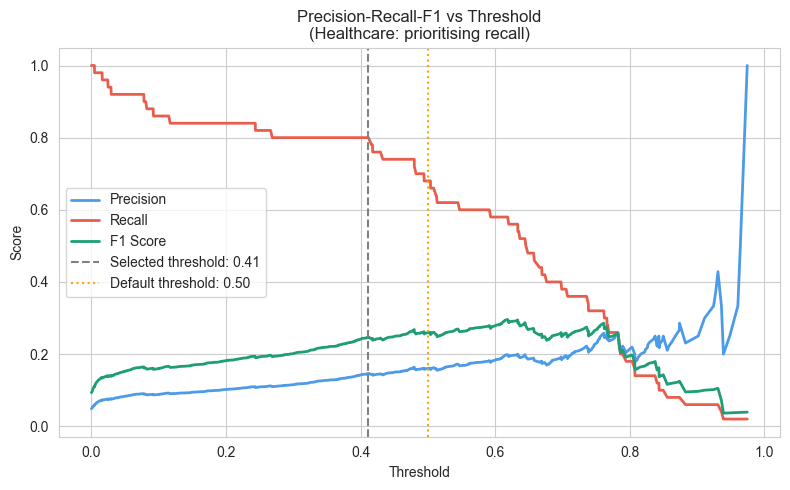


Final evaluation at selected threshold (0.41):

Model: XGBoost (recall-optimised)  |  Threshold: 0.4117729961872101
ROC-AUC : 0.8201
F1 Score: 0.2477

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.99      0.76      0.86       972
      Stroke       0.15      0.80      0.25        50

    accuracy                           0.76      1022
   macro avg       0.57      0.78      0.55      1022
weighted avg       0.95      0.76      0.83      1022

Confusion Matrix:
[[739 233]
 [ 10  40]]


In [43]:
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_prob)

# Find threshold where stroke recall >= 0.75
# In healthcare we prioritize recall over precision
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Strategy: find threshold that gives recall >= 0.75 with best precision
target_recall = 0.75
valid_idx = np.where(recalls[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    # Among all thresholds with recall >= 0.75, pick highest F1
    best_idx = valid_idx[np.argmax(f1_scores[valid_idx])]
    best_threshold = thresholds[best_idx]
else:
    # Fallback to max F1
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]

print(f"Default threshold (0.50) → Stroke recall: 0.68, catches 34/50")
print(f"Optimal threshold ({best_threshold:.2f}) → targeting recall ≥ 0.75")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#4C9BE8', linewidth=2)
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='#E85D4C', linewidth=2)
plt.plot(thresholds, f1_scores[:-1],  label='F1 Score',  color='#1D9E75', linewidth=2)
plt.axvline(best_threshold, color='gray', linestyle='--',
            label=f'Selected threshold: {best_threshold:.2f}')
plt.axvline(0.50, color='orange', linestyle=':', linewidth=1.5,
            label='Default threshold: 0.50')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall-F1 vs Threshold\n(Healthcare: prioritising recall)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal evaluation at selected threshold ({best_threshold:.2f}):")
xgb_auc_final, xgb_f1_final, _ = evaluate_model(
    "XGBoost (recall-optimised)", xgb_model, X_test, y_test,
    threshold=best_threshold
)

In [44]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import ADASYN

# SMOTETomek - oversample minority + clean boundary noise
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)
print("SMOTETomek distribution:", pd.Series(y_train_smt).value_counts())

# ADASYN - focuses synthetic samples on harder-to-classify cases
adasyn = ADASYN(random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)
print("ADASYN distribution:", pd.Series(y_train_ada).value_counts())

SMOTETomek distribution: stroke
0    3515
1    3515
Name: count, dtype: int64
ADASYN distribution: stroke
0    3889
1    3883
Name: count, dtype: int64


In [46]:
results = {}

for name, X_res, y_res in [
    ("SMOTE (current)",  X_train_sm,  y_train_sm),
    ("SMOTETomek",       X_train_smt, y_train_smt),
    ("ADASYN",           X_train_ada, y_train_ada)
]:
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_res, y_res, eval_set=[(X_test, y_test)], verbose=False)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.41).astype(int)
    
    auc    = roc_auc_score(y_test, y_prob)
    recall = y_pred[y_test == 1].mean()
    caught = y_pred[y_test == 1].sum()
    fp     = ((y_pred == 1) & (y_test == 0)).sum()
    
    results[name] = {
        'ROC-AUC': round(auc, 4),
        'Recall' : round(recall, 4),
        'Caught' : int(caught),
        'False Alarms': int(fp)
    }
    print(f"\n{name}: AUC={auc:.4f} | Recall={recall:.4f} | Caught={caught}/50 | FP={fp}")

print("\n=== Summary ===")
print(pd.DataFrame(results).T)


SMOTE (current): AUC=0.8201 | Recall=0.8000 | Caught=40/50 | FP=234

SMOTETomek: AUC=0.8260 | Recall=0.7800 | Caught=39/50 | FP=243

ADASYN: AUC=0.8130 | Recall=0.7600 | Caught=38/50 | FP=232

=== Summary ===
                 ROC-AUC  Recall  Caught  False Alarms
SMOTE (current)   0.8201    0.80    40.0         234.0
SMOTETomek        0.8260    0.78    39.0         243.0
ADASYN            0.8130    0.76    38.0         232.0


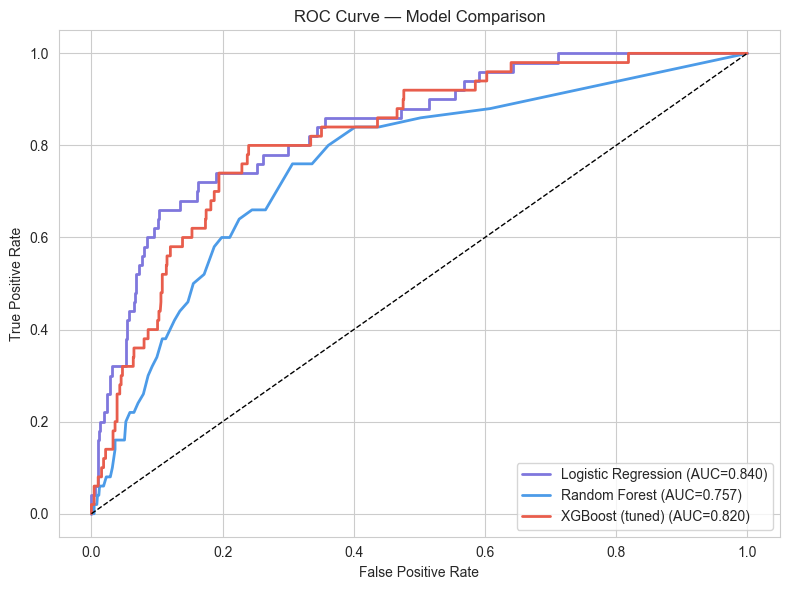

In [48]:
plt.figure(figsize=(8, 6))

for name, prob, color in [
    ("Logistic Regression", lr_prob,  '#7F77DD'),
    ("Random Forest",       rf_prob,  '#4C9BE8'),
    ("XGBoost (tuned)",     xgb_prob, '#E85D4C')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

plt.plot([0,1],[0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

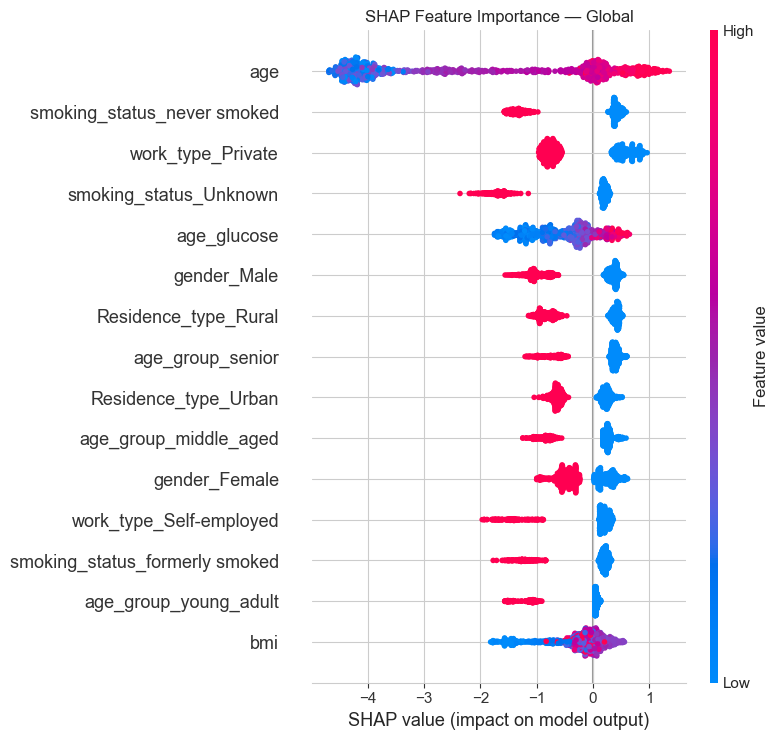

SHAP global plot saved


In [49]:
explainer   = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('SHAP Feature Importance — Global')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP global plot saved")

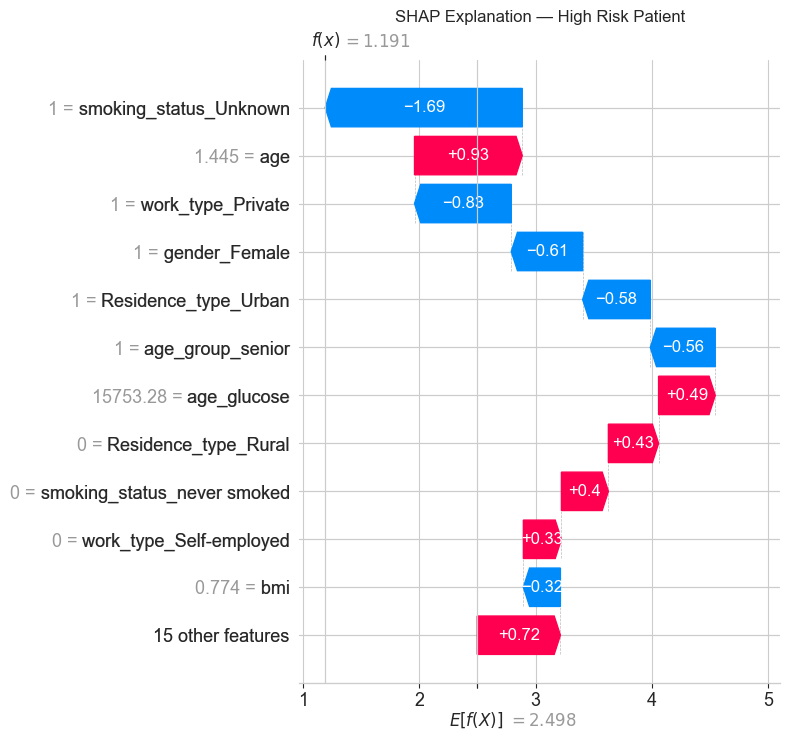

SHAP waterfall saved


In [50]:
# Find a true stroke patient in test set for a compelling demo
stroke_indices = y_test[y_test == 1].index
test_reset     = X_test.reset_index(drop=True)
y_test_reset   = y_test.reset_index(drop=True)
stroke_idx     = y_test_reset[y_test_reset == 1].index[0]

plt.figure()
shap.waterfall_plot(shap_values[stroke_idx], show=False, max_display=12)
plt.title('SHAP Explanation — High Risk Patient')
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP waterfall saved")

In [51]:
model_bundle = {
    'model'          : xgb_model,
    'scaler'         : joblib.load('../data/scaler.pkl'),
    'feature_columns': joblib.load('../data/feature_columns.pkl'),
    'threshold'      : best_threshold,
    'model_name'     : 'XGBoost (Optuna tuned)',
    'best_roc_auc'   : xgb_auc_final,
    'best_f1'        : xgb_f1_final
}

joblib.dump(model_bundle, '../backend/model.pkl')
print("Model bundle saved to backend/model.pkl")
print(f"Threshold : {best_threshold:.4f}")
print(f"ROC-AUC   : {xgb_auc_final:.4f}")
print(f"F1 Score  : {xgb_f1_final:.4f}")

Model bundle saved to backend/model.pkl
Threshold : 0.4118
ROC-AUC   : 0.8201
F1 Score  : 0.2477


In [52]:
# Save final summary - useful reference for Phase 4
import joblib

# Verify model bundle is intact
bundle = joblib.load('../backend/model.pkl')
print("=== Model Bundle Verification ===")
print(f"Model     : {bundle['model_name']}")
print(f"Threshold : {bundle['threshold']:.4f}")
print(f"ROC-AUC   : {bundle['best_roc_auc']:.4f}")
print(f"Features  : {len(bundle['feature_columns'])} columns")
print(f"\nFeature columns saved: {bundle['feature_columns']}")
print("\nAll good — safe to close.")

=== Model Bundle Verification ===
Model     : XGBoost (Optuna tuned)
Threshold : 0.4118
ROC-AUC   : 0.8201
Features  : 26 columns

Feature columns saved: ['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'bmi', 'age_glucose', 'high_risk_comorbidity', 'gender_Female', 'gender_Male', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Rural', 'Residence_type_Urban', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'age_group_child', 'age_group_elderly', 'age_group_middle_aged', 'age_group_senior', 'age_group_young_adult']

All good — safe to close.
